# CIBUSmod example
This notebook privides a step-by-step example of how the model is run and how outputs can be visualised. The model is currently a work in progress, so this notebook will be continuosly updated as the work progresses.

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [101]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [102]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read data on current crop areas and animal numbers
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form. In the future a separate class will likely be constructed to handle this.

In [103]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})
x0_ani_raw = x0_ani.copy()

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='slaktkycklingar','poultry',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='hästar','horses',x0_ani['species'])

# Add horse breeds
x0_ani = pd.concat([
    x0_ani[x0_ani.animal != 'hästar'],
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'ponnyer'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'kallblod'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'ridhästar'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'trav och galopp'})
    ])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='slaktkycklingar','broiler',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='ponnyer','ponies and Icelandic horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kallblod','cold blooded horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='ridhästar','riding horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='trav och galopp','trotters and racehorses',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

# Numbers per horse breed
x0_ani.update(x0_ani.xs(('horses','ponies and Icelandic horses'),level=('species','breed'),drop_level=False) * 0.297)  
x0_ani.update(x0_ani.xs(('horses','cold blooded horses'),level=('species','breed'),drop_level=False) * 0.100)  
x0_ani.update(x0_ani.xs(('horses','riding horses'),level=('species','breed'),drop_level=False) * 0.343)  
x0_ani.update(x0_ani.xs(('horses','trotters and racehorses'),level=('species','breed'),drop_level=False) * 0.260)  

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

## Run test scenario 'baseline'
This test scenario includes ...
1. population increase according to World Bank projections (parameter='population'),
1. a 17% increase in milk yield per cow from 2020 to 2050 that is stronger initially and then levels off (parameter='milk_prod'),
2. an overall yield increase of 5% from 2020 to 2050 for all crops (parameter='yield'),
3. a 1% year-on-year decrease in pig meat consumption up until 2040 (parameter='consumption').

The scenario is defined in the different parameter Excel files in 'data/production_parameters' under the sheets named 'scn_baseline'

### Set up scenario and modules

Select the 'baseline' scenario, define years to calculate output for and create a container to store output per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [104]:
# Define scenario, years and create output container
scn = 'baseline'
years = ['2020','2030','2040','2050']
output = pd.DataFrame(
    columns=['crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':scn,'year':years}))
)

Next, we initialise all model modules (python classes) that handle the calculations.

Each module is intialised with a **ParameterRetriever** object which reads a supplied parameter Excel-file and handles the retrieval of parameter values used in the calculations. The **ParameterRetriever** also handles updating parameter values according to a scenario.

There are three main modules that stores data as attributes (generaly in the form of pandas.DataFrames). These are:

**DemandAndConversions:**
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

**CropProduction:**
This module calculates production of crop products per unit (area) of crop in a certain region.

**AnimalHerd:**
This module has subclasses for each animal species (and breed) and is initialised as one AnimalHerd object per species (e.g. cattle) + breed (e.g. dairy) + production system (e.g. conventional) + sub system (used to represent different feeding strategies, e.g. maize based) combination. The **AnimalHerd** modules calculates production of animal products per animal unit (i.e. a defining animal in the species/breed). The defining animal differs accros species/breeds with e.g. 'cows' for **CattleHerd**s, 'sows+gilts' for **PigHerd**s and 'total horses' for **HorseHerd**s.

The there are also a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

**FeedMgmt:**
Handles the calculation of feed requirements, losses and import shares and the translation from 'feed products' to 'crop products' and 'by-products'.

**ManureMgmt:**
Handles the calculation of manure excretion and losses in stables and storage. Currently only nitrogen is implemented.

**FertiliserMgmt:**
Handles the calculation of crop fertiliser requirements and application of manure and mineral fertiliser. Currently calculates only plant available nitrogen requirements.

Finaly the module **GeoDistributor** handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [105]:
# Instantiate diet class
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','DemandAndConversions.xlsx')
    )
)

# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','CropProduction.xlsx')),
    index = x0_crp.index
)    

# Instantiate animal herds
# Each animal herd object is stored in an indexed pandas.Series
# A function will be developed to handle this in a more user-friendly way
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        for ss in ['maize based','none'] if (ps == 'conventional') else ['none']:
            herds[(sp,br,ps,ss)] = \
                cm.CattleHerd(
                    par = cm.ParameterRetriever(
                        os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                    ),
                    index = x0_ani.index.get_level_values('region').unique(),
                    breed = br,
                    prod_system = ps,
                    sub_system = ss
                )
    elif sp == 'horses':
        herds[(sp,br,ps,'none')] = \
            cm.HorseHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','HorseHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )
    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','PigHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )
    elif sp == 'poultry':
        if br == 'broiler':
            herds[(sp,br,ps,'none')] = \
            cm.BroilerHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','BroilerHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FeedMgmt.xlsx'))
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','ManureMgmt.xlsx'))
)

# Instantiate fertiliser management
fertiliser_mgmt = cm.FertiliserMgmt(
    crops = crops,
    herds = herds,
    demand = demand,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FertiliserMgmt.xlsx'))
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    x0 = x0,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FertiliserMgmt.xlsx'))
)

### Run calculations
Now we have initialised all modules and can do the calculations. This is done by looping through the years and first updating all parameter values according to the speciefied scenario and year then (re-)calculating all classes and running the **GeoDistributor** to distribute crops and animals across regions. Finally the ouputs are stored.

**Note:** Warnings are printed because the 'baseline' scenario is not defined in all parameter sheets.

In [106]:
# Loop through years
for year in years:
    print(year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(scn,year)
    
    # Calculate food demand
    demand.calculate(verbose=True)

    # Calculate crops
    crops.calculate(
        verbose = True
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose = True)

    # Calculate feed
    feed_mgmt.calculate(verbose=True)    

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6], scale_power=[0.25,0], verbose=True)
    # Solve optimisation problem
    geodist.solve(
        verbose=True,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':1e-6,
            'eps_rel':1e-6,
            'verbose':False
        }
    )
    
    # Scale results
    crops.scale(geodist.x['crp'])
    for h in herds:
        h.scale(
            geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
            x_is = h.x_is
        )
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate fertiliser
    fertiliser_mgmt.calculate(verbose=True)
    
    # Store results
    # Crops
    output.loc[(scn,year),'crp'] = \
    crops.make_static()
    # Animals
    output.loc[(scn,year),'ani'] = \
    concat_herds(
        herds.apply(lambda x: x.make_static())
    )
    
    # Update x0 for next itt (To be implemented in GeoDistributor)
    geodist.x0['crp'] = geodist.x0['crp'].copy()
    geodist.x0['ani'].update(geodist.x['ani'].groupby(['species','breed','prod_system','region']).sum())

2020


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retrie

[11:32:45][Diet] Calculating food demand ...
[11:32:45][Diet] Calculating waste ...
[11:32:45][Diet] Calculating crop product demand ...
[11:32:45][Diet] Calculating crop product demand ...
[11:32:46][Diet] Done! Elapsed time: 1 sec
[11:32:46][CropProduction] Calculating harvest ...
[11:32:46][CropProduction] Calculating production ...
[11:32:49][CropProduction] Calculating seed demand ...
[11:32:51][CropProduction] Done! Elapsed time: 6 sec
[11:32:51][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:32:52][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:32:52][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:32:52][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:32:52][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:32:52][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:32:52][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


[11:35:54][FertiliserMgmt] Distributing manure ...
[11:35:54][FertiliserMgmt] Done! Elapsed time: 3 sec


...

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retrie

[11:44:58][Diet] Calculating food demand ...
[11:44:58][Diet] Calculating waste ...
[11:44:58][Diet] Calculating crop product demand ...
[11:44:58][Diet] Calculating crop product demand ...
[11:44:58][Diet] Done! Elapsed time: 1 sec
[11:44:58][CropProduction] Calculating harvest ...
[11:44:58][CropProduction] Calculating production ...
[11:45:02][CropProduction] Calculating seed demand ...
[11:45:04][CropProduction] Done! Elapsed time: 5 sec
[11:45:04][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:45:04][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:45:04][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:45:04][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:45:05][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:45:05][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:45:05][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


[11:46:50][FertiliserMgmt] Distributing manure ...
[11:46:50][FertiliserMgmt] Done! Elapsed time: 3 sec


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


## Plot output
Here are some example output plots.

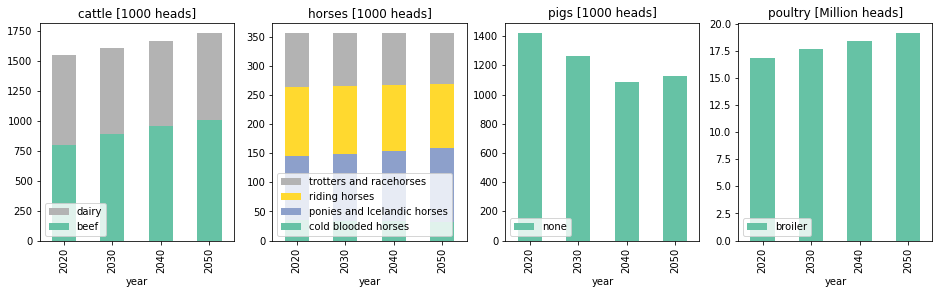

In [107]:
# Number of animal heads
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].heads.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

idxs = plot_data.columns.droplevel('breed').unique()

fig, axs = plt.subplots(1,4, figsize=(16,4))

n=0
for idx in idxs:
    
    ax=axs[n]
    
    (
        (plot_data / (1000000 if idx=='poultry' else 1000))
        .xs(idx,level='species',axis=1).
        reset_index().plot.bar(x='year', ax = ax, stacked=True, cmap='Set2')
    )
    
    ax.set_title(idx + (' [Million heads]' if idx=='poultry' else ' [1000 heads]'))
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='lower left')
    n += 1
        
plt.show()

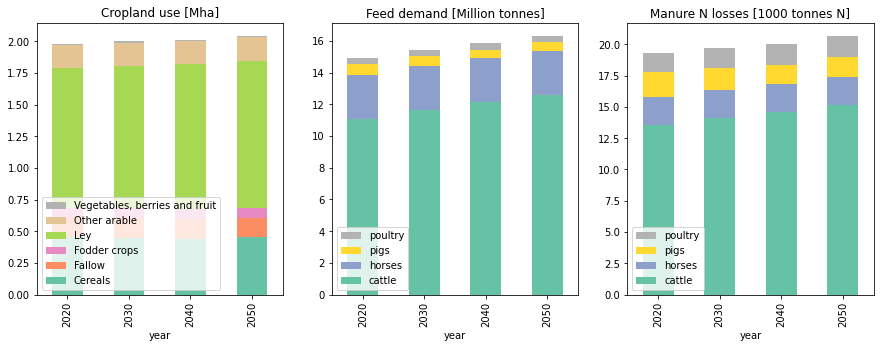

In [108]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

# Cropland use --->
ax = axs[0]
# crop --> crop_group
cg_rel = pd.Series(crops.par.get_rel('crop','crop_group')).rename('crop_group').rename_axis('crop')
# crop --> land_use
lu_rel = pd.Series(crops.par.get_rel('crop','land_use')).rename('land_use').rename_axis('crop')

# Make broader crop categories
cg_rel = cg_rel.replace({
    'Cereals, winter':'Cereals',
    'Cereals, spring':'Cereals',
    'Grain legumes':'Other arable',
    'Brassicaceae':'Other arable',
    'Potatoes':'Other arable',
    'Beets':'Other arable',
    'Energy crops':'Other arable',
    'Green manure':'Other arable',
    'Vegetables':'Vegetables, berries and fruit',
    'Berries':'Vegetables, berries and fruit',
    'Fruit trees':'Vegetables, berries and fruit',
})

idx = pd.IndexSlice

plot_data = pd.concat([
    (
        output.loc[(scn,y),'crp'].area.rename('area')
        .to_frame().join(cg_rel).join(lu_rel)
        .set_index('land_use', append=True)
        .loc[idx[:,:,:,'cropland']]
        .groupby('crop_group').sum()['area']
    )
    for y in years
], axis=1).T / 1000000
plot_data.index = pd.Index(years,name='year')
(
    plot_data.reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, cmap = 'Set2')
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')
ax.set_title('Cropland use [Mha]')

# Feed demand --->
ax = axs[1]
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].feed.crop_product_demand.groupby(['species'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T / 1000000000
plot_data.index = pd.Index(years,name='year')

(
    plot_data.reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, cmap = 'Set2')
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')
ax.set_title('Feed demand [Million tonnes]')

# N losses --->
ax = axs[2]
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].manure.N_loss.groupby(['species'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T / 1000000
plot_data.index = pd.Index(years,name='year')



(
    plot_data.reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, cmap = 'Set2')
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('Manure N losses [1000 tonnes N]')

plt.show()



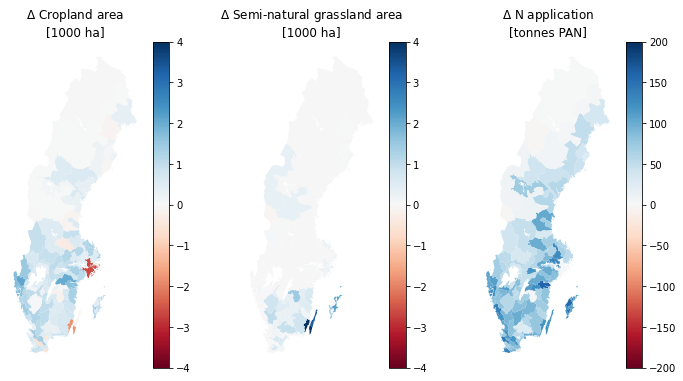

In [115]:
idx = pd.IndexSlice
fig, axs = plt.subplots(1,3, figsize=(12,6))

# Cropland area --->
ax = axs[0]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .area.rename('area').to_frame()
     .join(lu_rel).set_index('land_use', append=True)
     .loc[idx[:,:,:,'cropland']]
     .groupby('region').sum()/1000)['area']
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename('area').to_frame()
     .join(lu_rel).set_index('land_use', append=True)
     .loc[idx[:,:,:,'cropland']]
     .groupby('region').sum()/1000)['area'],
     cmap='RdBu',
     vmin=-4,
     vmax=4,
     ax=ax
)
ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
ax.set_axis_off()

# Grassland area --->
ax = axs[1]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .area.rename('area').to_frame()
     .join(lu_rel).set_index('land_use', append=True)
     .loc[idx[:,:,:,'semi-natural grasslands']]
     .groupby('region').sum()/1000)['area']
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename('area').to_frame()
     .join(lu_rel).set_index('land_use', append=True)
     .loc[idx[:,:,:,'semi-natural grasslands']]
     .groupby('region').sum()/1000)['area'],
     cmap='RdBu',
     vmin=-4,
     vmax=4,
     ax=ax
)
ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
ax.set_axis_off()

# N application --->
ax = axs[2]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .fertiliser.N_req.sum(axis=1)
     .groupby('region').sum()/1000
     -
    output.loc[(scn,'2020'),'crp']
     .fertiliser.N_req.sum(axis=1)
     .groupby('region').sum()/1000),
     cmap='RdBu',
     vmin=-200,
     vmax=200,
     ax=ax
)
ax.set_title('$\Delta$ N application\n[tonnes PAN]')
ax.set_axis_off()

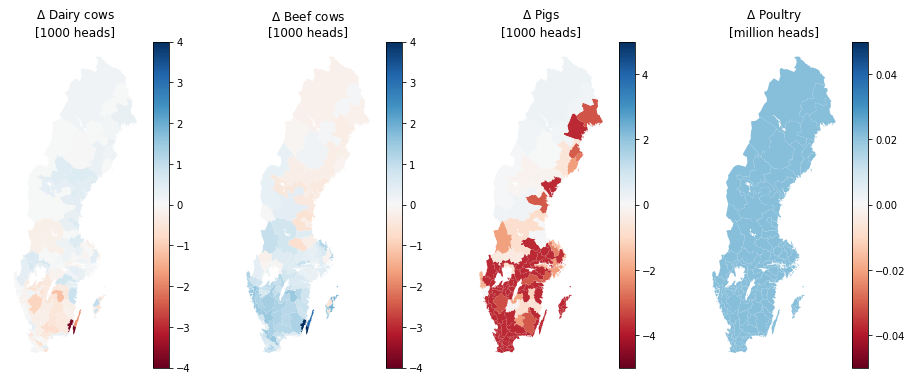

In [112]:
fig, axs = plt.subplots(1,4, figsize=(16,6))

# Dairy cows --->
ax = axs[0]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-4,
     vmax=4,
     ax=ax
)
ax.set_title('$\Delta$ Dairy cows\n[1000 heads]')
ax.set_axis_off()

# Beef cows --->
ax = axs[1]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-4,
     vmax=4,
     ax=ax
)
ax.set_title('$\Delta$ Beef cows\n[1000 heads]')
ax.set_axis_off()

# Pigs --->
ax = axs[2]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-5,
     vmax=5,
     ax=ax
)
ax.set_title('$\Delta$ Pigs\n[1000 heads]')
ax.set_axis_off()

# Poultry --->
ax = axs[3]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1)/1000000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1)/1000000),
     cmap='RdBu',
     vmin=-0.05,
     vmax=0.05,
     ax=ax
)
ax.set_title('$\Delta$ Poultry\n[million heads]')
ax.set_axis_off()